## Attention Mechanism

In this chapter we will implement the attention mechanism which presents the relationship between the tokens so we will be able to find the relationships in the long sequences.

For example, in a language to language translation task, we must not translate the sentence word by word. Instead, LLM must detect and understand the differences like in the grammatical structure between the translated and the target languages. To do so, attention mechanism is the core subject in transformers architecture.

Attention mechanism can be applied not just for text inputs but also for multi-modal inputs like image or speech recognition.

We will implement 3 types of attention mechanism in order within this notebook.
1. Implementation of self-attention
2. Implementation of causal attention
3. Implementation of multi-head attention

### Self-Attention

"Self" refers to the ability of relating different positions within a single input sequence.

We need to use the embedding vectors of each token to find how much one token relates to another token.

Instead of converting a text to embedding vectors from scratch, we can assume the following inputs tensor related with the words written next to each vector.

Here the `inputs` tensor represents 6 words and each word has 3 dimensional embedding vector.

In [5]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)

print(inputs.shape)

torch.Size([6, 3])


So, now we can start applying self-attention to the embedding vectors of each word.

Self-attention is basically applied as the dot product between two vectors.

Dot product of two vectors can be written in two ways as shown below.

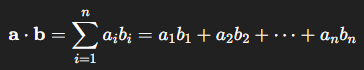

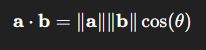

Using the second equation, we can say that the dot product includes the calculation of how well the projection of the first vector is applied on the second vector.

Since there is `cosine` term in the equation and it has a boundary between -1 and +1, the lower the cosine angle means the better projection so the higher amount of dot product as a result.

If we normalize the dot product with the magnitudes of two vectors, we can obtain another definition called `cosine similarity`. This can also be used as similarity between two vectors.

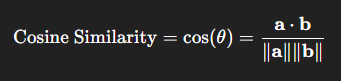

We can calculate dot product with `PyTorch` using `dot` method. Or, we can simply multiply two vectors and sum the elements of the final vector.

In [14]:
dot1 = torch.sum(inputs[0, :] * inputs[1, :])
dot2 = torch.dot(inputs[0, :], inputs[1, :])

assert dot1 == dot2

print("Dot product 1: ", dot1)
print("Dot product 2: ", dot2)

Dot product 1:  tensor(0.9544)
Dot product 2:  tensor(0.9544)


So, we can basically write a for loop to calculate the dot product between each vectors.
Since there are 6 embedding vectors in `inputs`, we must get 6 x 6 matrix after the calculation of dot product.

In [24]:
num_embedding_vector = inputs.shape[0]
dot_product_matrix = torch.zeros((num_embedding_vector, num_embedding_vector))

for row_idx in range(inputs.shape[0]):
    for col_idx in range(inputs.shape[0]):
        dot_product_matrix[row_idx, col_idx] = torch.dot(inputs[row_idx, :], inputs[col_idx, :])

print("Dot product matrix:")
print(dot_product_matrix)

Dot product matrix:
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Instead of using `torch.dot` in a for loop, we can use matrix multiplication.

`torch.matmul` or `@` symbol can be used for matrix multiplication.

In [28]:
inputs @ inputs.T

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In the matrix, the second element, `dot_product_matrix[0][1] = 0.9544`, calculates the similarity between the 1st embedding vector and the 2nd embedding vector in `inputs` matrix.

Similarly, the 17th element, `dot_product_matrix[2][4] = 0.7154`, calculates the similarity between the 3rd embedding vector and the 5th embedding vector in `inputs` matrix.